# Model 1 — Flood Prediction (Kerala, LSGD-level, live place-name query)

**What this notebook does end to end:** trains a flood risk model on Kerala's 1,034 LSGD
units, then lets you type a place name and get a live prediction using two data sources:

1. **Google Earth Engine (static terrain features)** — elevation, slope, distance to water,
   vegetation/built-up %. These come from `lsgd_feature_store.csv`, which Notebook 00 already
   built using GEE (SRTM DEM, JRC Global Surface Water, ESA WorldCover). **Terrain doesn't
   change day to day, so it's looked up instantly from that precomputed table rather than
   re-querying GEE on every search** — GEE is still very much part of the pipeline, just used
   once upfront instead of on every query.
2. **A weather API (live rainfall)** — this IS fetched fresh every time you type a place name,
   using Open-Meteo (free, no API key). Rainfall is the one input that genuinely changes day
   to day, so this is the part that makes a query feel "live."

**Honest scope note carried over from earlier validation work:** ground-truth labels
(`flood_occurred`) are only known at DISTRICT level (14 districts) from 2018 KSDMA records,
not true per-LSGD level. This notebook keeps the honest grouped validation checks built
earlier so you can see the real, non-leaked accuracy alongside the model.

## 1. Setup

In [2]:
!pip install -q xgboost lightgbm scikit-learn pandas matplotlib seaborn joblib requests geopandas geemap earthengine-api

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import requests
import joblib
import json
import geopandas as gpd
from datetime import date, timedelta
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.base import clone
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import ee
from google.colab import drive

np.random.seed(42)
drive.mount('/content/drive')
BASE = '/content/drive/MyDrive/DIP_Kerala'

# GEE is initialized here mainly so this notebook is self-contained and could re-run Notebook
# 00's terrain extraction if the feature store ever needs rebuilding -- day-to-day queries below
# don't call GEE directly, they read the already-extracted values from lsgd_feature_store.csv.
ee.Authenticate()
ee.Initialize(project='dip-kerala-502817')

Mounted at /content/drive


## 2. Load the feature store (GEE-derived terrain + Open-Meteo historical rainfall + labels)

In [3]:
df = pd.read_csv(f'{BASE}/03_processed/lsgd_feature_store.csv')
print(df.shape)
df.head()

(1034, 24)


,lsgd_id,lsgd_name,lsgd_type,district,elevation,slope,rainfall_7day_mm,event_year_x,dist_to_water_m,vegetation,...,fully_damaged_houses,severely_damaged_houses,roads_damaged_km,bridges_damaged,severity_score,flood_risk_level,landslide_risk_level,flood_occurred,landslide_occurred,event_year_y
0,1,Vorkady,gram_panchayat,Kasaragod,59.011230,7.386920,285.2,2018,4374.374389,0.937367,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Manjeswaram,gram_panchayat,Kasaragod,21.380619,4.270908,230.5,2018,1516.365486,0.800916,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Paivalike,gram_panchayat,Kasaragod,88.465243,8.798889,285.9,2018,7627.278746,0.877275,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Meenja,gram_panchayat,Kasaragod,52.726992,6.329972,252.0,2018,3464.459376,0.850222,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Mangalpaddy,gram_panchayat,Kasaragod,23.913829,4.745512,252.0,2018,1553.752487,0.856307,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
feature_cols = ['elevation', 'slope', 'rainfall_7day_mm', 'dist_to_water_m', 'vegetation', 'builtup']
target_col = 'flood_occurred'

df = df.dropna(subset=feature_cols + [target_col])
X = df[feature_cols]
y = df[target_col].astype(int)

print(X.shape, y.shape)
print(y.value_counts())

(993, 6) (993,)
flood_occurred
1    581
0    412
Name: count, dtype: int64


## 3. Train / test split and scaling

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (794, 6)  Test: (199, 6)


## 4. Train Random Forest, XGBoost, LightGBM

In [6]:
models = {
    'RandomForest': RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42, verbose=-1),
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, probs) if len(set(y_test)) > 1 else float('nan')
    results[name] = {'model': model, 'preds': preds, 'probs': probs, 'auc': auc}
    print(f"\n===== {name} =====")
    print(classification_report(y_test, preds, zero_division=0))
    print("ROC-AUC:", round(auc, 4) if auc == auc else "undefined (only one class in test split)")


===== RandomForest =====
              precision    recall  f1-score   support

           0       0.71      0.61      0.66        83
           1       0.75      0.82      0.78       116

    accuracy                           0.73       199
   macro avg       0.73      0.72      0.72       199
weighted avg       0.73      0.73      0.73       199

ROC-AUC: 0.8181

===== XGBoost =====
              precision    recall  f1-score   support

           0       0.78      0.59      0.67        83
           1       0.75      0.88      0.81       116

    accuracy                           0.76       199
   macro avg       0.76      0.73      0.74       199
weighted avg       0.76      0.76      0.75       199

ROC-AUC: 0.8114

===== LightGBM =====
              precision    recall  f1-score   support

           0       0.77      0.59      0.67        83
           1       0.75      0.87      0.80       116

    accuracy                           0.75       199
   macro avg       0.76    

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


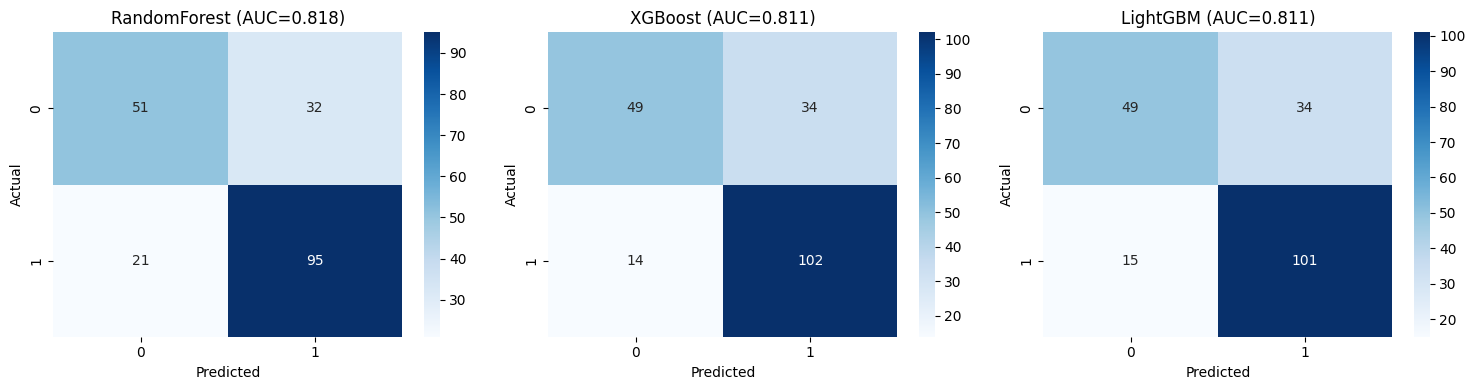

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f"{name} (AUC={r['auc']:.3f})" if r['auc'] == r['auc'] else name)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

## 5. Honest validation — grouped by district (carried over from earlier diagnostic work)

Random splits can let units from the same district leak between train/test (they share a
label). This repeats a grouped split across many seeds and averages, since with only 14
districts a single split can be unstable or degenerate (e.g. a test set with only one class).

In [8]:
valid = {k: v for k, v in results.items() if v['auc'] == v['auc']}
best_name = max(valid, key=lambda k: valid[k]['auc']) if valid else list(results.keys())[0]
best_model = results[best_name]['model']
print(f"Best model (random split): {best_name}")

groups = df.loc[X.index, 'district']
import warnings
n_repeats = 30
accs = []
for seed in range(n_repeats):
    gss_r = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
    tr_idx, te_idx = next(gss_r.split(X, y, groups=groups))
    if len(set(y.iloc[te_idx])) < 2:
        continue
    Xtr, Xte = X.iloc[tr_idx], X.iloc[te_idx]
    ytr, yte = y.iloc[tr_idx], y.iloc[te_idx]
    sc = StandardScaler()
    Xtr_s, Xte_s = sc.fit_transform(Xtr), sc.transform(Xte)
    m = clone(models[best_name])
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        m.fit(Xtr_s, ytr)
    accs.append((m.predict(Xte_s) == yte.values).mean())

print(f"Ran {len(accs)}/{n_repeats} splits with both classes present in test")
print(f"Mean grouped-split accuracy: {np.mean(accs):.4f} (std: {np.std(accs):.4f})")
print(f"Range: {np.min(accs):.4f} - {np.max(accs):.4f}")
print("\nReport THIS mean as the honest accuracy -- not the random-split number above.")
print("A number here much lower than the random-split result confirms district-level leakage.")

Best model (random split): RandomForest
Ran 20/30 splits with both classes present in test
Mean grouped-split accuracy: 0.5084 (std: 0.1054)
Range: 0.2621 - 0.6963

Report THIS mean as the honest accuracy -- not the random-split number above.
A number here much lower than the random-split result confirms district-level leakage.


## 6. Save the trained model

In [9]:
import os
os.makedirs(f'{BASE}/05_models', exist_ok=True)
joblib.dump(best_model, f'{BASE}/05_models/flood_model.pkl')
joblib.dump(scaler, f'{BASE}/05_models/flood_scaler.pkl')
print('Saved to', f'{BASE}/05_models/')

Saved to /content/drive/MyDrive/DIP_Kerala/05_models/


In [10]:
print("="*50)
print("FLOOD MODEL -- FINAL ACCURACY SUMMARY")
print("="*50)
print(f"Model: {best_name}")
print(f"Random-split accuracy (optimistic, may include leakage): {(results[best_name]['preds'] == y_test.values).mean():.4f}")
print(f"Honest district-grouped accuracy (report THIS one):       {np.mean(accs):.4f}")
print("="*50)

accuracy_summary = {
    'model': best_name,
    'random_split_accuracy': float((results[best_name]['preds'] == y_test.values).mean()),
    'honest_grouped_accuracy_mean': float(np.mean(accs)),
    'honest_grouped_accuracy_std': float(np.std(accs)),
}
with open(f'{BASE}/05_models/flood_accuracy.json', 'w') as f:
    json.dump(accuracy_summary, f, indent=2)
print(f"\nSaved accuracy summary to {BASE}/05_models/flood_accuracy.json (Notebook 04 reads this)")

FLOOD MODEL -- FINAL ACCURACY SUMMARY
Model: RandomForest
Random-split accuracy (optimistic, may include leakage): 0.7337
Honest district-grouped accuracy (report THIS one):       0.5084

Saved accuracy summary to /content/drive/MyDrive/DIP_Kerala/05_models/flood_accuracy.json (Notebook 04 reads this)


## 7. Live place-name query — GEE static features + live weather API rainfall

This is the actual "type a place name, get a prediction" tool.

- **Static features (from GEE, via the feature store):** elevation, slope, distance to water,
  vegetation %, built-up % — looked up instantly, no live GEE call needed since terrain is stable.
- **Live feature (from the weather API, fetched right now):** rainfall over the past 7 days,
  from Open-Meteo — this is what changes every time you run this cell on a different day.

In [11]:
lsgd = gpd.read_file(f'{BASE}/00_boundaries/kerala_lsgd_boundaries.geojson')
rename_map = {'local_auth': 'lsgd_type', 'name': 'lsgd_name', 'District': 'district'}
lsgd = lsgd.rename(columns={k: v for k, v in rename_map.items() if k in lsgd.columns})
if 'lsgd_id' not in lsgd.columns:
    lsgd['lsgd_id'] = range(1, len(lsgd) + 1)

lsgd_wgs84 = lsgd.to_crs(epsg=4326)
lsgd_wgs84['centroid'] = lsgd_wgs84.geometry.centroid
lsgd_wgs84['lat'] = lsgd_wgs84['centroid'].y
lsgd_wgs84['lon'] = lsgd_wgs84['centroid'].x

def fetch_live_weather(lat, lon):
    """Live rainfall (past 7 days, matching the training window) + current conditions for display."""
    end_date = date.today()
    start_date = end_date - timedelta(days=6)
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": lat, "longitude": lon,
        "start_date": start_date.isoformat(), "end_date": end_date.isoformat(),
        "daily": "precipitation_sum",
        "current": "temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m",
        "timezone": "auto",
    }
    r = requests.get(url, params=params, timeout=15)
    r.raise_for_status()
    data = r.json()
    daily = data.get('daily', {})
    values = [v for v in daily.get('precipitation_sum', []) if v is not None]
    return {
        'rainfall_7day_mm': sum(values) if values else 0.0,
        'daily_breakdown': dict(zip(daily.get('time', []), daily.get('precipitation_sum', []))),
        'current': data.get('current', {}),
    }

def predict_flood_risk(place_name):
    row = lsgd_wgs84[lsgd_wgs84['lsgd_name'].str.lower() == place_name.lower()]
    if row.empty:
        row = lsgd_wgs84[lsgd_wgs84['lsgd_name'].str.lower().str.contains(place_name.lower(), na=False)]
    if row.empty:
        print(f"'{place_name}' not found. Check spelling or try the district name.")
        return None
    row = row.iloc[0]

    static = df[df['lsgd_id'] == row['lsgd_id']]
    if static.empty:
        print(f"No feature store entry for lsgd_id {row['lsgd_id']}. Was Notebook 00 run for this unit?")
        return None
    static = static.iloc[0]

    weather = fetch_live_weather(row['lat'], row['lon'])

    X_place = pd.DataFrame([{
        'elevation': static['elevation'],
        'slope': static['slope'],
        'rainfall_7day_mm': weather['rainfall_7day_mm'],  # LIVE value, not the training-time one
        'dist_to_water_m': static['dist_to_water_m'],
        'vegetation': static['vegetation'],
        'builtup': static['builtup'],
    }])[feature_cols]

    prob = best_model.predict_proba(scaler.transform(X_place))[0][1]
    risk = "HIGH" if prob > 0.7 else "MODERATE" if prob > 0.4 else "LOW"
    current = weather['current']

    print(f"Location: {row['lsgd_name']} ({row['lsgd_type']}, {row['district']} district)")
    print(f"\n--- Live Weather (Open-Meteo, fetched just now) ---")
    print(f"Current temperature: {current.get('temperature_2m', 'n/a')} C")
    print(f"Current humidity: {current.get('relative_humidity_2m', 'n/a')}%")
    print(f"Rainfall, past 7 days: {weather['rainfall_7day_mm']:.1f} mm")
    print(f"Daily breakdown: {weather['daily_breakdown']}")
    print(f"\n--- Static terrain (Google Earth Engine, precomputed) ---")
    print(f"Elevation: {static['elevation']:.1f} m | Slope: {static['slope']:.2f} deg")
    print(f"Distance to water: {static['dist_to_water_m']:.0f} m | Vegetation: {static['vegetation']*100:.1f}% | Built-up: {static['builtup']*100:.1f}%")
    print(f"\n--- Flood Risk Prediction ---")
    print(f"Flood probability: {prob*100:.1f}%  ->  {risk}")

    return {'place': row['lsgd_name'], 'district': row['district'], 'flood_probability': prob, 'risk': risk}

# Try it:
# predict_flood_risk("Chengannur")

/tmp/ipykernel_2390/542541827.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lsgd_wgs84['centroid'] = lsgd_wgs84.geometry.centroid


## Known limitations to state honestly in your report

- **Labels are district-level, not per-LSGD** — see Section 5's honest validation numbers.
  A grouped-split accuracy meaningfully lower than the random-split number confirms leakage
  was inflating the naive result. Getting genuinely higher, trustworthy accuracy requires
  real per-unit ground truth (e.g. NRSC/Bhuvan flood-extent maps overlaid on LSGD polygons),
  not more model tuning on the current labels.
- **"Live" here means "fetched when you run the cell,"** not a continuously streaming system —
  turning this into an always-on alert system would need this deployed as a scheduled backend
  job, which is future work.
- **Terrain features are static by design** — elevation/slope/water/land-cover don't need to
  be re-fetched from GEE per query; only rainfall is live. If Kerala's land cover changes
  significantly over time, re-run Notebook 00 periodically to refresh the feature store.